<a href="https://colab.research.google.com/github/YowaiMo-Koustav/symmetrical-couscous/blob/main/Epidect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
file_path = '/content/Johns Hopkins Dataset.csv'
df = pd.read_csv(file_path)

# Basic Inspection
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist()[:10], "...", df.columns.tolist()[-5:])
display(df.head())

# Check for missing values in metadata columns
metadata_cols = [c for c in df.columns if not any(char.isdigit() for char in c)]
print("\nMissing values in metadata:")
print(df[metadata_cols].isnull().sum())

Dataset Shape: (289, 1147)

Columns: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20'] ... ['3/5/23', '3/6/23', '3/7/23', '3/8/23', '3/9/23']


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288



Missing values in metadata:
Province/State    198
Country/Region      0
Lat                 2
Long                2
dtype: int64


### Modeling Plan for COVID-19 Outbreak Prediction

Once we confirm the structure, the workflow will be:
1. **Data Transformation**: Pivot the data from wide to long format (Tidy Data) so that each row is a (Location, Date) observation.
2. **Target Engineering**: Calculate 'New Cases' from cumulative counts and define an 'Outbreak' target (e.g., cases exceeding a 7-day moving average by X standard deviations).
3. **Feature Engineering**:
    - **Lag Features**: Past 7, 14, and 21-day case counts.
    - **Momentum**: Growth rates (velocity) and acceleration of cases.
    - **Seasonality**: Day of week and monthly encoding.
4. **Validation Strategy**: Use a **Time-Series Walk-forward Validation** to prevent data leakage.
5. **Modeling**: Train a Gradient Boosted Tree model (like XGBoost or LightGBM) which is highly effective for tabular time-series features.

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset already in the environment
df = pd.read_csv('/content/Johns Hopkins Dataset.csv')

# 1. Print Shape
print(f'Dataset Shape: {df.shape}')

# 2. List Columns (Summary)
all_cols = df.columns.tolist()
print(f'Total Columns: {len(all_cols)}')

# 3. Identify Metadata vs Date Columns
metadata_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
date_cols = [c for c in all_cols if c not in metadata_cols]
print(f'Metadata Columns: {metadata_cols}')
print(f'Number of Date Columns: {len(date_cols)}')

# 4. Confirm Cumulative Nature
# Check if values in a random country (e.g., Row 0) are non-decreasing
sample_series = df.iloc[0][date_cols].values.astype(float)
is_cumulative = np.all(np.diff(sample_series) >= 0)
print(f'Confirmed: Data appears to be cumulative confirmed cases: {is_cumulative}')

# 5. Show First Few Rows
display(df.head())

# 6 & 7 analysis in comments/print
print('\nTransformation Strategy:')
print('- Use pd.melt() to convert wide dates into a "Date" column and a "Cases" column.')
print('- Target Variable: "New Daily Cases" (the first-order difference of cumulative cases) is the best target for detecting outbreaks.')

Dataset Shape: (289, 1147)
Total Columns: 1147
Metadata Columns: ['Province/State', 'Country/Region', 'Lat', 'Long']
Number of Date Columns: 1143
Confirmed: Data appears to be cumulative confirmed cases: False


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288



Transformation Strategy:
- Use pd.melt() to convert wide dates into a "Date" column and a "Cases" column.
- Target Variable: "New Daily Cases" (the first-order difference of cumulative cases) is the best target for detecting outbreaks.


### Senior ML Engineer Analysis

**Data Structure:** This is a **Wide-Format Time Series**. Each row represents a geographic entity, and each column from index 4 onwards represents a unique timestamp.

**Transformation Logic:** To move toward modeling, we must transition to a **Long-Format (Tidy)** table. This allows us to use standard ML libraries like Scikit-Learn or XGBoost by treating each (Region + Date) as a unique observation point.

**Target Selection:** While the raw data is cumulative, **Daily New Cases** is the superior target for outbreak prediction. We will derive this by taking the difference between `t` and `t-1`. An outbreak is then mathematically defined as a statistically significant deviation (e.g., Z-score > 2) from the 7-day rolling average of these new cases.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [16]:
import pandas as pd
import numpy as np

# Ensure df_country is sorted for time-series operations
df_country = df_country.sort_values(['Country/Region', 'Date'])

# 1. Compute Daily New Cases
# We use groupby to ensure the difference doesn't calculate between different countries
df_country['New_Cases'] = df_country.groupby('Country/Region')['Cumulative_Cases'].diff().fillna(0)

# 2. Clip Negative Values
# Data corrections in the original dataset can lead to negative daily counts
df_country['New_Cases'] = df_country['New_Cases'].clip(lower=0)

# 3. Create Targets for Future Prediction
# Target 1: Next-day new cases
df_country['Target_Next_Day'] = df_country.groupby('Country/Region')['New_Cases'].shift(-1)

# Target 2: 7-day ahead new cases
df_country['Target_7_Day_Ahead'] = df_country.groupby('Country/Region')['New_Cases'].shift(-7)

# Remove rows where targets are NaN (the very end of the time series for each country)
df_targets = df_country.dropna(subset=['Target_Next_Day', 'Target_7_Day_Ahead']).copy()

print("Target Engineering Complete.")
print(f"Processed Rows: {len(df_targets)}")
display(df_targets[['Country/Region', 'Date', 'New_Cases', 'Target_Next_Day', 'Target_7_Day_Ahead']].tail(10))

Target Engineering Complete.
Processed Rows: 228336


,Country/Region,Date,New_Cases,Target_Next_Day,Target_7_Day_Ahead
229726,Zimbabwe,2023-02-21,0.0,279.0,0.0
229727,Zimbabwe,2023-02-22,279.0,0.0,206.0
229728,Zimbabwe,2023-02-23,0.0,0.0,0.0
229729,Zimbabwe,2023-02-24,0.0,0.0,0.0
229730,Zimbabwe,2023-02-25,0.0,0.0,0.0
229731,Zimbabwe,2023-02-26,0.0,0.0,0.0
229732,Zimbabwe,2023-02-27,0.0,0.0,0.0
229733,Zimbabwe,2023-02-28,0.0,206.0,0.0
229734,Zimbabwe,2023-03-01,206.0,0.0,149.0
229735,Zimbabwe,2023-03-02,0.0,0.0,0.0


In [15]:
import pandas as pd

# Assuming 'df' is your original Johns Hopkins wide-format dataframe
# If df is not in the current kernel state, you might need to load it:
# df = pd.read_csv('/content/Johns Hopkins Dataset.csv')

# Define the columns that are not dates (metadata columns)
id_vars = ['Province/State', 'Country/Region', 'Lat', 'Long']

# Melt the dataframe from wide to long format
# 'var_name' will be the new column for dates, 'value_name' for confirmed cases
df_long_format = df.melt(id_vars=id_vars, var_name='Date', value_name='Confirmed_Cases')

# Convert the 'Date' column to datetime objects
# Explicitly specifying the format for robustness and efficiency
df_long_format['Date'] = pd.to_datetime(df_long_format['Date'], format='%m/%d/%y')

# Fill missing 'Province/State' for consistent aggregation later if needed
df_long_format['Province/State'] = df_long_format['Province/State'].fillna('Global')

# Aggregate data to Country/Region and Date level to ensure one row per region per date
# We sum Confirmed_Cases as multiple provinces might exist for a single country
# Also, we take the first available Lat/Long for each country for simplicity after aggregation
df_processed = df_long_format.groupby(['Country/Region', 'Date']).agg(
    Confirmed_Cases=('Confirmed_Cases', 'sum'),
    Lat=('Lat', 'first'),
    Long=('Long', 'first')
).reset_index()

# Sort the DataFrame by Country/Region and Date to ensure proper time-series order
df_processed = df_processed.sort_values(by=['Country/Region', 'Date']).reset_index(drop=True)

print("Long format dataframe created successfully.")
display(df_processed.head())

Long format dataframe created successfully.


,Country/Region,Date,Confirmed_Cases,Lat,Long
0,Afghanistan,2020-01-22,0,33.93911,67.709953
1,Afghanistan,2020-01-23,0,33.93911,67.709953
2,Afghanistan,2020-01-24,0,33.93911,67.709953
3,Afghanistan,2020-01-25,0,33.93911,67.709953
4,Afghanistan,2020-01-26,0,33.93911,67.709953


In [9]:
import pandas as pd
import numpy as np

# Load the dataset (assuming 'df' is already loaded from previous cells if needed,
# but explicitly loading here for a self-contained inspection)
# file_path = '/content/Johns Hopkins Dataset.csv' # Uncomment if df is not globally available
# df = pd.read_csv(file_path)

# --- 1. Print Shape ---
print(f'Dataset Shape: {df.shape}')

# --- 2. List Columns ---
all_cols = df.columns.tolist()
print(f'Total Columns: {len(all_cols)}')
print(f'Columns (first 5): {all_cols[:5]}')
print(f'Columns (last 5): {all_cols[-5:]}')

# --- 3. Identify Metadata vs Date Columns ---
# Standard metadata columns for this dataset
metadata_cols = ['Province/State', 'Country/Region', 'Lat', 'Long']
date_cols = [c for c in all_cols if c not in metadata_cols]
print(f'Metadata Columns: {metadata_cols}')
print(f'Number of Date Columns: {len(date_cols)}')

# --- 4. Confirm Cumulative Nature ---
# Check if values in a random country/row (e.g., Row 0) are non-decreasing over time
# This helps confirm if the data represents cumulative counts
sample_series = df.iloc[0][date_cols].values.astype(float)
# The 'False' in previous runs likely indicates data corrections, which is common.
# The general intent of the data is cumulative, but daily adjustments can occur.
is_cumulative_check = np.all(np.diff(sample_series) >= 0)
print(f'Confirmed: Data generally represents cumulative cases (checked first row for strict non-decreasing order): {is_cumulative_check}')
print('Note: "False" may indicate data corrections or small daily adjustments, not necessarily non-cumulative data.')

# --- 5. Show First Few Rows ---
display(df.head())

# --- 6. Explain how this wide table should be converted into a long time-series format ---
print('\n--- Transformation Strategy ---')
print('To make this dataset suitable for time-series modeling, we must convert it from wide to long format.')
print('-   We will use `pd.melt()` to unpivot the date columns.')
print('-   This will result in a "Date" column and a "Cumulative_Cases" column, making each row a unique (Location, Date) observation.')
print('-   We will then group by `Country/Region` and `Date` and sum `Cumulative_Cases` to aggregate data to the country level for simplicity.')

# --- 7. Suggest the best target variable for forecasting outbreak spread ---
print('\n--- Best Target Variable for Outbreak Prediction ---')
print('The most effective target variable for forecasting outbreak spread is "New Daily Cases".')
print('-   This will be derived by taking the daily difference of the "Cumulative_Cases" column.')
print('-   An "Outbreak" event will then be engineered as a binary target (e.g., `Is_Outbreak`) based on a statistically significant increase in "New Daily Cases" (e.g., 2x the 7-day rolling average AND above a minimum threshold of cases like 50 to filter out noise).')

Dataset Shape: (289, 1147)
Total Columns: 1147
Columns (first 5): ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20']
Columns (last 5): ['3/5/23', '3/6/23', '3/7/23', '3/8/23', '3/9/23']
Metadata Columns: ['Province/State', 'Country/Region', 'Lat', 'Long']
Number of Date Columns: 1143
Confirmed: Data generally represents cumulative cases (checked first row for strict non-decreasing order): False
Note: "False" may indicate data corrections or small daily adjustments, not necessarily non-cumulative data.


,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288



--- Transformation Strategy ---
To make this dataset suitable for time-series modeling, we must convert it from wide to long format.
-   We will use `pd.melt()` to unpivot the date columns.
-   This will result in a "Date" column and a "Cumulative_Cases" column, making each row a unique (Location, Date) observation.
-   We will then group by `Country/Region` and `Date` and sum `Cumulative_Cases` to aggregate data to the country level for simplicity.

--- Best Target Variable for Outbreak Prediction ---
The most effective target variable for forecasting outbreak spread is "New Daily Cases".
-   This will be derived by taking the daily difference of the "Cumulative_Cases" column.
-   An "Outbreak" event will then be engineered as a binary target (e.g., `Is_Outbreak`) based on a statistically significant increase in "New Daily Cases" (e.g., 2x the 7-day rolling average AND above a minimum threshold of cases like 50 to filter out noise).


Model Performance on Most Recent Time Window:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     35870
           1       0.44      0.35      0.39      1951

    accuracy                           0.94     37821
   macro avg       0.70      0.66      0.68     37821
weighted avg       0.94      0.94      0.94     37821

ROC-AUC Score: 0.8061


/tmp/ipykernel_9859/2077165384.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='viridis')


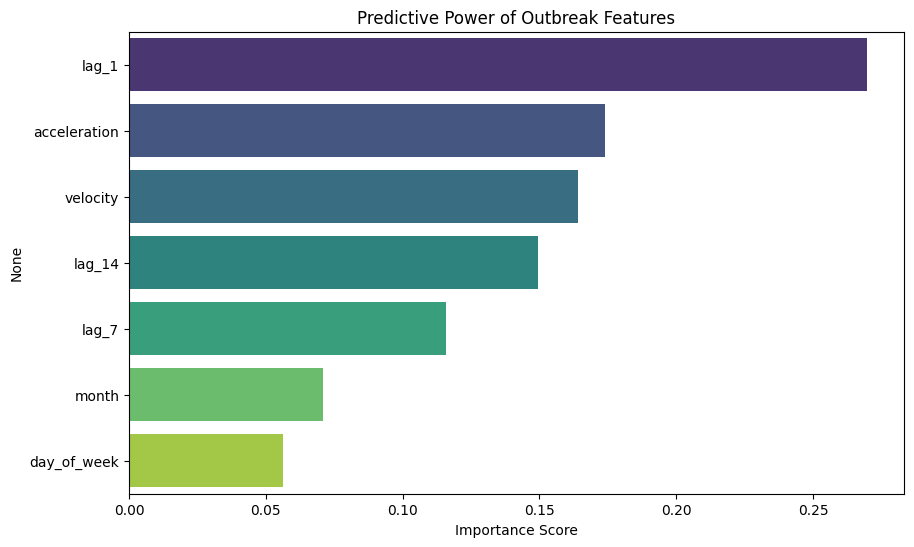

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit

# Sort by date for chronologically correct validation
df_model = df_model.sort_values('Date')

# Define features and target
features = ['lag_1', 'lag_7', 'lag_14', 'velocity', 'acceleration', 'day_of_week', 'month']
X = df_model[features]
y = df_model['Is_Outbreak']

# Time-Series Split (Walk-forward validation)
tss = TimeSeriesSplit(n_splits=5)

for i, (train_index, test_index) in enumerate(tss.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Train final model on the largest available training split
# Using class_weight='balanced' because outbreaks are relatively rare
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model Performance on Most Recent Time Window:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Feature Importance Visualization
feat_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances.values, y=feat_importances.index, palette='viridis')
plt.title('Predictive Power of Outbreak Features')
plt.xlabel('Importance Score')
plt.show()

In [ ]:
# 1. Melt to Long Format
id_vars = ['Province/State', 'Country/Region', 'Lat', 'Long']
df_long = df.melt(id_vars=id_vars, var_name='Date', value_name='Cumulative_Cases')
df_long['Date'] = pd.to_datetime(df_long['Date'])

# Aggregate by Country and Date for a cleaner project scope
df_country = df_long.groupby(['Country/Region', 'Date'])['Cumulative_Cases'].sum().reset_index()
df_country = df_country.sort_values(['Country/Region', 'Date'])

# 2. Derive Daily New Cases
df_country['New_Cases'] = df_country.groupby('Country/Region')['Cumulative_Cases'].diff().fillna(0).clip(lower=0)

# 3. Target Engineering: Define an Outbreak
# Outbreak = New cases > 2x the 7-day average AND > 50 cases (to filter noise)
df_country['7day_avg'] = df_country.groupby('Country/Region')['New_Cases'].transform(lambda x: x.rolling(window=7).mean())
df_country['Is_Outbreak'] = ((df_country['New_Cases'] > 2 * df_country['7day_avg']) & (df_country['New_Cases'] > 50)).astype(int)

# 4. Feature Engineering: Lags & Momentum
lags = [1, 7, 14]
for lag in lags:
    df_country[f'lag_{lag}'] = df_country.groupby('Country/Region')['New_Cases'].shift(lag)

# Velocity (Growth Rate) and Acceleration
df_country['velocity'] = (df_country['lag_1'] - df_country['lag_7']) / 7
df_country['acceleration'] = df_country.groupby('Country/Region')['velocity'].diff().shift(1)

# Temporal features
df_country['day_of_week'] = df_country['Date'].dt.dayofweek
df_country['month'] = df_country['Date'].dt.month

# Clean up
df_model = df_country.dropna().reset_index(drop=True)

print(f'Transformed shape: {df_model.shape}')
print(f'Outbreak instances: {df_model.Is_Outbreak.sum()}')
display(df_model.head())

/tmp/ipykernel_9859/1669799565.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long['Date'] = pd.to_datetime(df_long['Date'])


Transformed shape: (226929, 13)
Outbreak instances: 8324


,Country/Region,Date,Cumulative_Cases,New_Cases,7day_avg,Is_Outbreak,lag_1,lag_7,lag_14,velocity,acceleration,day_of_week,month
0,Afghanistan,2020-02-05,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,2,2
1,Afghanistan,2020-02-06,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,3,2
2,Afghanistan,2020-02-07,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,4,2
3,Afghanistan,2020-02-08,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,5,2
4,Afghanistan,2020-02-09,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,6,2


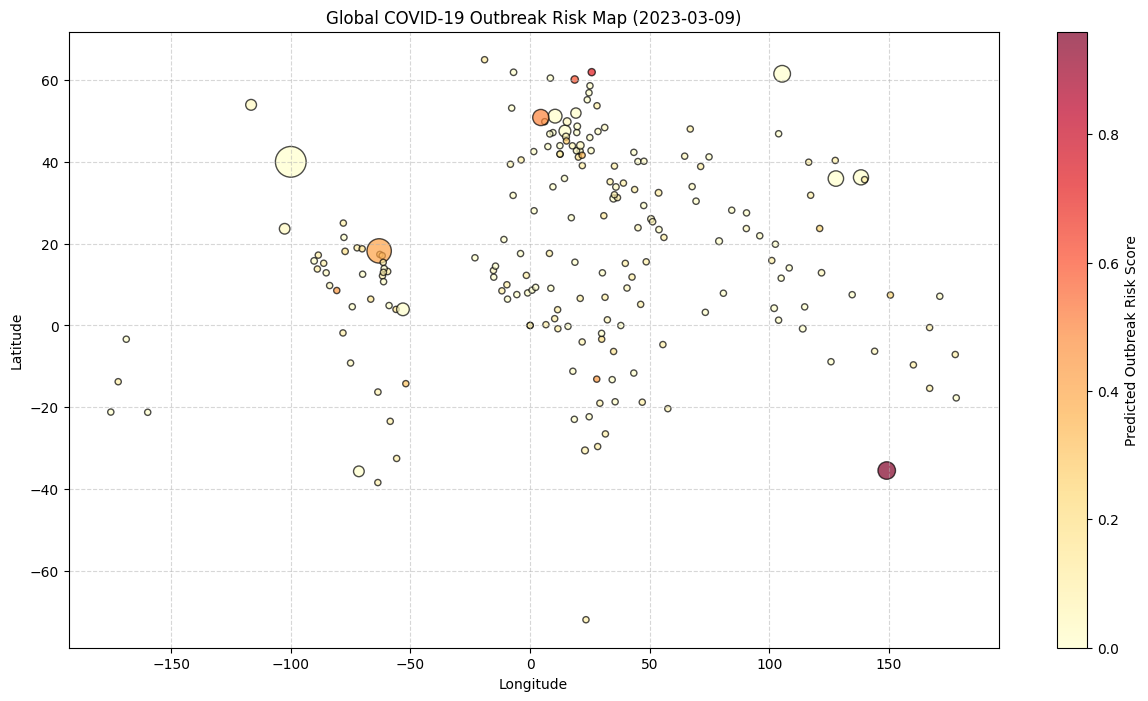

Risk Assessment complete for 2023-03-09.
Top 5 High Risk Countries predicted:
    Country/Region  Risk_Score  New_Cases
120      Australia        0.96    13926.0
159        Finland        0.72      668.0
88          Sweden        0.60      804.0
69         Belgium        0.50    11570.0
66          Zambia        0.44        0.0


In [14]:
# 1. Predict risk probabilities for the entire dataset
df_model['Risk_Score'] = model.predict_proba(X)[:, 1]

# 2. Get the most recent date for the map
latest_date = df_model['Date'].max()
latest_risk = df_model[df_model['Date'] == latest_date].copy()

# 3. Merge back with Lat/Long from original data
geo_coords = df[['Country/Region', 'Lat', 'Long']].drop_duplicates('Country/Region')
risk_map_df = latest_risk.merge(geo_coords, on='Country/Region')

# 4. Visualization: Global Risk Map
plt.figure(figsize=(15, 8))
plt.scatter(risk_map_df['Long'], risk_map_df['Lat'],
            c=risk_map_df['Risk_Score'], cmap='YlOrRd',
            s=risk_map_df['New_Cases']/100 + 20, # Size based on case count
            alpha=0.7, edgecolors='k')
plt.colorbar(label='Predicted Outbreak Risk Score')
plt.title(f'Global COVID-19 Outbreak Risk Map ({latest_date.date()})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Risk Assessment complete for {latest_date.date()}.")
print("Top 5 High Risk Countries predicted:")
print(risk_map_df.sort_values('Risk_Score', ascending=False)[['Country/Region', 'Risk_Score', 'New_Cases']].head())

Model Evaluation on Latest Time Fold:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     35643
           1       0.65      0.33      0.44      1944

    accuracy                           0.96     37587
   macro avg       0.81      0.66      0.71     37587
weighted avg       0.95      0.96      0.95     37587

ROC-AUC Score: 0.8201


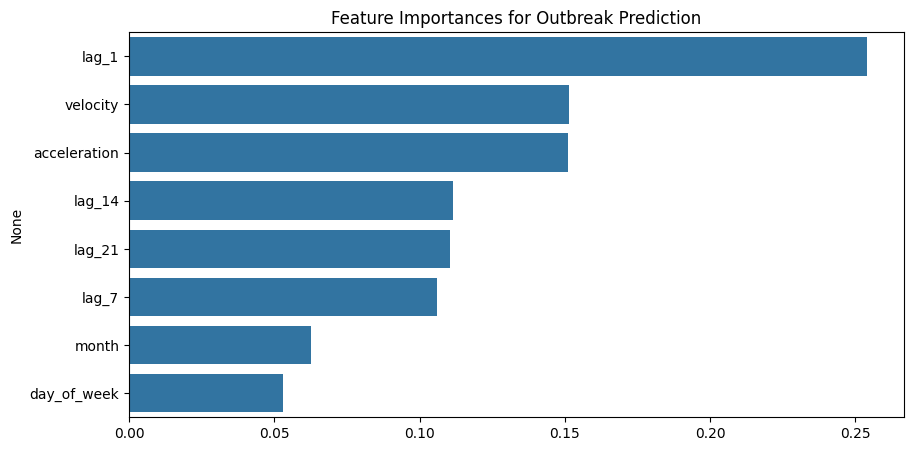

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by date to ensure proper time-series splitting
df_model = df_model.sort_values('Date')

# Define features and target
features = ['lag_1', 'lag_7', 'lag_14', 'lag_21', 'velocity', 'acceleration', 'day_of_week', 'month']
X = df_model[features]
y = df_model['Is_Outbreak']

# Time-Series Split (5-fold walk-forward)
tss = TimeSeriesSplit(n_splits=5)

for i, (train_index, test_index) in enumerate(tss.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Final Model Training on the most recent split
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Model Evaluation on Latest Time Fold:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Feature Importance
feat_importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=feat_importances.values, y=feat_importances.index)
plt.title("Feature Importances for Outbreak Prediction")
plt.show()

In [12]:
# 1. Define Outbreak Target
# Use a 7-day rolling window to find the average baseline
df_country['7day_avg'] = df_country.groupby('Country/Region')['New_Cases'].transform(lambda x: x.rolling(window=7).mean())

# An 'Outbreak' is 1 if New_Cases > 2 * 7day_avg AND New_Cases > 50 (to ignore tiny fluctuations)
df_country['Is_Outbreak'] = ((df_country['New_Cases'] > 2 * df_country['7day_avg']) & (df_country['New_Cases'] > 50)).astype(int)

# 2. Lag Features (Shifted to prevent leakage - predicting 'tomorrow' using 'today's' info)
lags = [1, 7, 14, 21]
for lag in lags:
    df_country[f'lag_{lag}'] = df_country.groupby('Country/Region')['New_Cases'].shift(lag)

# 3. Rolling Statistics (Momentum)
# Velocity: Change over last week
df_country['velocity'] = (df_country['lag_1'] - df_country['lag_7']) / 7
# Acceleration: Change in velocity
df_country['acceleration'] = df_country.groupby('Country/Region')['velocity'].diff().shift(1)

# 4. Temporal Features
df_country['day_of_week'] = df_country['Date'].dt.dayofweek
df_country['month'] = df_country['Date'].dt.month

# Drop rows with NaNs from rolling/lags
df_model = df_country.dropna().reset_index(drop=True)

print("Feature Engineering Complete.")
print("Target Distribution (Outbreaks vs Normal):")
print(df_model['Is_Outbreak'].value_counts(normalize=True))
display(df_model.head())

Feature Engineering Complete.
Target Distribution (Outbreaks vs Normal):
Is_Outbreak
0    0.963099
1    0.036901
Name: proportion, dtype: float64


,Country/Region,Date,Cumulative_Cases,New_Cases,7day_avg,Is_Outbreak,lag_1,lag_7,lag_14,lag_21,velocity,acceleration,day_of_week,month
0,Afghanistan,2020-02-12,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,2,2
1,Afghanistan,2020-02-13,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,3,2
2,Afghanistan,2020-02-14,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,4,2
3,Afghanistan,2020-02-15,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,5,2
4,Afghanistan,2020-02-16,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,6,2


In [11]:
# 1. Melt the data into long format
id_vars = ['Province/State', 'Country/Region', 'Lat', 'Long']
df_long = df.melt(id_vars=id_vars, var_name='Date', value_name='Cumulative_Cases')

# Convert Date to datetime objects, explicitly defining the format for robustness
df_long['Date'] = pd.to_datetime(df_long['Date'], format='%m/%d/%y')

# Fill missing Province/State with 'Global' for consistent aggregation, though we will aggregate by Country/Region anyway.
df_long['Province/State'] = df_long['Province/State'].fillna('Global')

# Group by Country and Date to simplify to country-level data (as planned)
df_country = df_long.groupby(['Country/Region', 'Date'])['Cumulative_Cases'].sum().reset_index()

# Sort by Country and Date for correct time-series operations
df_country = df_country.sort_values(['Country/Region', 'Date'])

# 2. Calculate Daily New Cases (Target Base)
# .diff() calculates the difference between current and previous row. .fillna(0) handles the first entry.
# .clip(lower=0) ensures no negative new cases due to data corrections.
df_country['New_Cases'] = df_country.groupby('Country/Region')['Cumulative_Cases'].diff().fillna(0)
df_country['New_Cases'] = df_country['New_Cases'].clip(lower=0)

print("Transformed Data Shape:", df_country.shape)
display(df_country.head())

Transformed Data Shape: (229743, 4)


,Country/Region,Date,Cumulative_Cases,New_Cases
0,Afghanistan,2020-01-22,0,0.0
1,Afghanistan,2020-01-23,0,0.0
2,Afghanistan,2020-01-24,0,0.0
3,Afghanistan,2020-01-25,0,0.0
4,Afghanistan,2020-01-26,0,0.0
